# Step 1

# 에너지 사용량 예측 AI 모델

**데이터셋**: KAMP 자원 최적화 AI 데이터셋 (okm_augumented_2021.csv)  
**출처**: www.kamp-ai.kr  
**목표**: 15분 단위 피크 전력(kW) 예측 → 연간 기본 전기료 절감

---

### 모델링 프로세스 요약

**Target**: `15분` (15분 단위 최대수요전력, 단위: kW)

**1단계** 데이터 로드 및 기본 정보 확인 (.info / .describe)  
**2단계** EDA — 분포 시각화, 타겟 분포, 생산량-전력 관계  
**3단계** 결측치 / 이상치 확인 및 처리  
**4단계** 상관관계 분석 (Heatmap)  
**5단계** 변수 조합 설계 — Feature Set A / B / C  
**6단계** Train / Test Split + 스케일링  
**7단계** 모델 학습 — LinearReg / Ridge / DecisionTree / RandomForest / XGBoost / DNN  
**8단계** 하이퍼파라미터 튜닝 (GridSearchCV / RandomizedSearchCV)  
**9단계** 최종 모델 선정 및 종합 평가  
**10단계** 모델 저장 (pipeline.pkl)

# Step 2

In [4]:
import subprocess
import sys

required = {
    'xgboost'       : 'xgboost',
    'sklearn'       : 'scikit-learn',
    'pandas'        : 'pandas',
    'numpy'         : 'numpy',
    'matplotlib'    : 'matplotlib',
    'seaborn'       : 'seaborn',
    'joblib'        : 'joblib',
}

print("=== 라이브러리 설치 확인 ===\n")
for import_name, pkg_name in required.items():
    try:
        __import__(import_name)
        print(f"  ✅ {pkg_name:20s} 이미 설치됨")
    except ImportError:
        print(f"  ⚙️  {pkg_name:20s} 설치 중...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               pkg_name, '--break-system-packages', '-q'])
        print(f"  ✅ {pkg_name:20s} 설치 완료")

print("\n✅ 모든 라이브러리 준비 완료 → STEP 3으로 이동하세요!")

=== 라이브러리 설치 확인 ===

  ✅ xgboost              이미 설치됨
  ✅ scikit-learn         이미 설치됨
  ✅ pandas               이미 설치됨
  ✅ numpy                이미 설치됨
  ✅ matplotlib           이미 설치됨
  ✅ seaborn              이미 설치됨
  ✅ joblib               이미 설치됨

✅ 모든 라이브러리 준비 완료 → STEP 3으로 이동하세요!


# 필요 라이브러리 설치 확인 (최초 1회만 실행)
# !pip install xgboost --break-system-packages
# !pip install scikit-learn --break-system-packages

# Step 3

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows) ──────────────────────────
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── 한글 폰트 설정 (Windows) ──────────────────────────
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 임포트 완료")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")

✅ 라이브러리 임포트 완료
  pandas  : 2.1.4
  numpy   : 1.26.4
✅ 라이브러리 임포트 완료
  pandas  : 2.1.4
  numpy   : 1.26.4


# Step 4

In [8]:
import os

# 현재 작업 디렉토리 확인
print(f"현재 작업 경로: {os.getcwd()}")

현재 작업 경로: c:\Users\Admin\hipython\ml


In [9]:
import os
import pandas as pd

# 가능한 경로 후보 목록
candidates = [
    r'C:\Users\Admin\hipython\data\okm_augumented_2021.csv',
    r'C:\Users\Admin\hipython\ml\data\okm_augumented_2021.csv',
    './data/okm_augumented_2021.csv',
]

# 존재하는 경로 자동 탐지
file_path = None
for path in candidates:
    if os.path.exists(path):
        file_path = path
        print(f"✅ 파일 발견: {file_path}")
        break

if file_path is None:
    print("❌ 파일을 찾지 못했습니다. 경로를 확인하세요.")
    print(f"   현재 작업 경로: {os.getcwd()}")
else:
    df = pd.read_csv(file_path)
    print(f"\n✅ 데이터 로드 완료")
    print(f"   행(row) 수 : {df.shape[0]:,}")
    print(f"   열(col) 수 : {df.shape[1]}")
    print()
    print("=== 컬럼 목록 ===")
    print(df.columns.tolist())
    print()
    print("=== 상위 5행 ===")
    display(df.head())

✅ 파일 발견: C:\Users\Admin\hipython\data\okm_augumented_2021.csv

✅ 데이터 로드 완료
   행(row) 수 : 6,168
   열(col) 수 : 18

=== 컬럼 목록 ===
['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']

=== 상위 5행 ===


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


# Step 5

In [10]:
print("=== .info() — 컬럼별 타입 및 결측치 ===")
df.info()

=== .info() — 컬럼별 타입 및 결측치 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


# Step 6

In [11]:
print("=== .describe() — 기술통계 ===")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

=== .describe() — 기술통계 ===


,count,mean,std,min,25%,50%,75%,max
날짜,6168.000000,20210492.299611,244.775577,20210101.000000,20210306.000000,20210509.000000,20210712.000000,20210914.000000
시간,6168.000000,12.428016,12.847309,0.000000,6.000000,12.000000,18.000000,188.000000
15분,6168.000000,90.410182,55.349403,0.000000,23.000000,101.000000,133.000000,207.000000
30분,6168.000000,92.695363,57.942122,0.000000,23.000000,104.000000,143.000000,222.000000
45분,6168.000000,95.106355,59.285709,0.000000,23.000000,105.000000,149.000000,218.000000
60분,6168.000000,95.037938,59.347554,0.000000,23.000000,107.000000,149.000000,214.000000
평균,6168.000000,93.424125,57.355938,0.000000,23.000000,104.000000,144.000000,208.000000
생산량,6168.000000,467.344682,857.571815,0.000000,0.000000,45.000000,637.250000,9830.000000
기온,6168.000000,15.906064,9.160356,-12.000000,9.600000,17.400000,23.300000,33.400000
풍속,6165.000000,2.063633,1.164118,0.000000,1.200000,1.900000,2.800000,7.600000


# Step 7

In [12]:
print("=== 결측치 현황 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    '결측치 수': missing,
    '결측률(%)': missing_pct
}).query('`결측치 수` > 0')

print(missing_df)
print(f"\n총 결측치 수 : {missing.sum()}개")
print(f"결측치 있는 컬럼 : {len(missing_df)}개")

=== 결측치 현황 ===
      결측치 수  결측률(%)
풍속        3    0.05
강수량       1    0.02
공장인원     17    0.28

총 결측치 수 : 21개
결측치 있는 컬럼 : 3개


# Step 8

=== 이상치 확인 ===
[시간] 최대값: 188  (정상: 0~23)
       시간 > 23 인 행: 48건

[15분 피크전력] 최소: 0 / 최대: 207 / 평균: 90.4
                피크전력 = 0 인 행: 19건

[생산량] 0인 행: 2657건 (43.1%)  ← 비가동 시간

[공장인원] 최소: 0.00 / 최대: 48.39



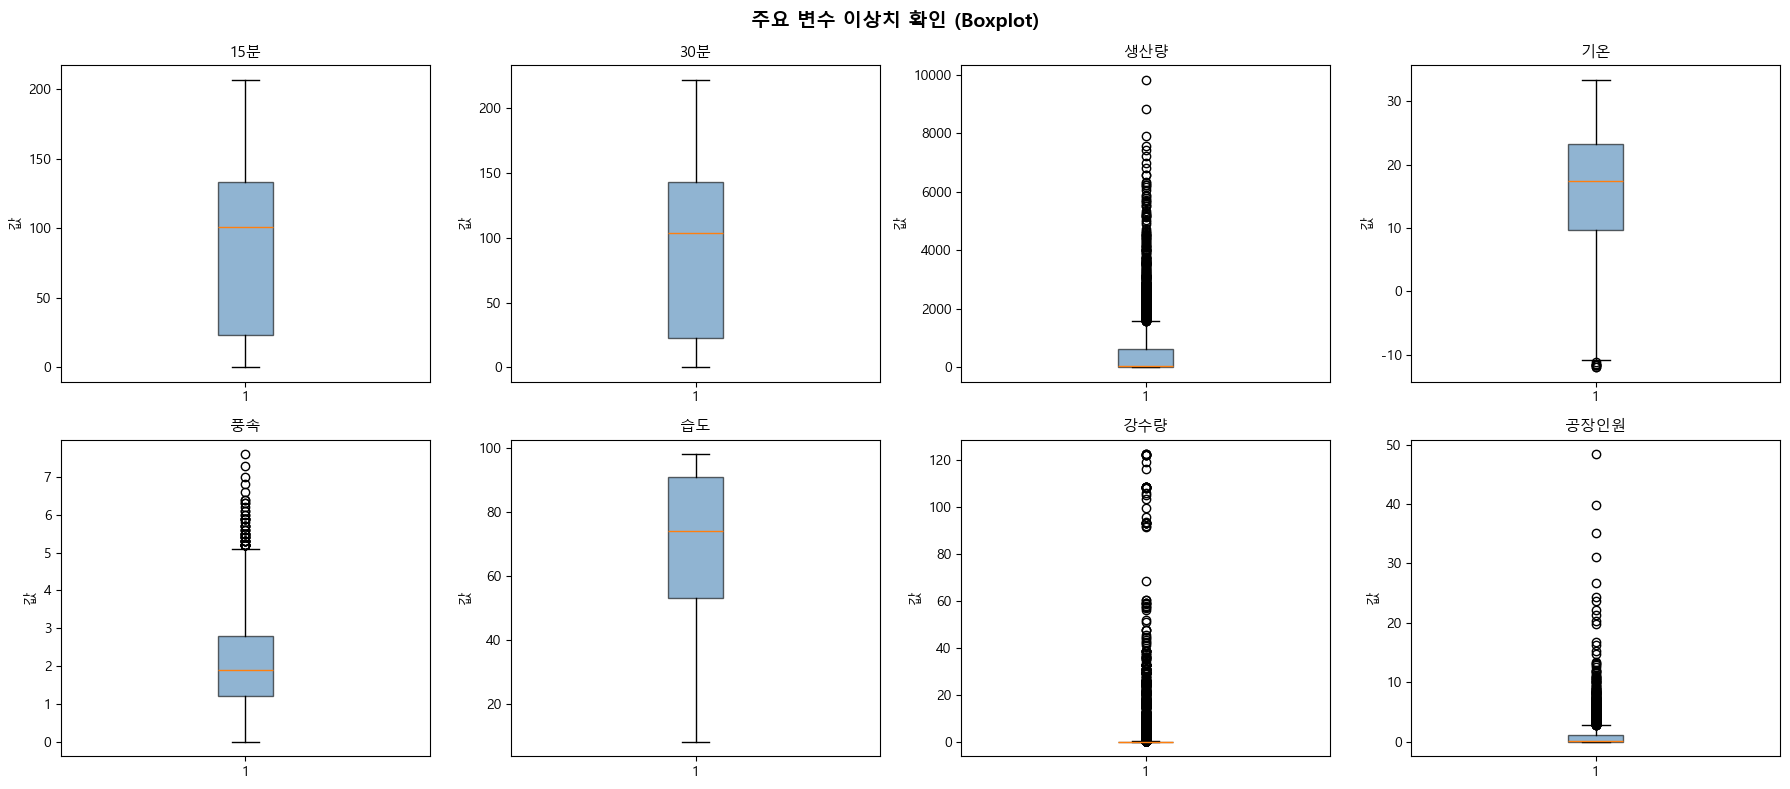

In [13]:
print("=== 이상치 확인 ===")

# 1) 시간 컬럼: 0~23이 정상
print(f"[시간] 최대값: {df['시간'].max()}  (정상: 0~23)")
print(f"       시간 > 23 인 행: {(df['시간'] > 23).sum()}건")
print()

# 2) 타겟 변수 분포
print(f"[15분 피크전력] 최소: {df['15분'].min()} / 최대: {df['15분'].max()} / 평균: {df['15분'].mean():.1f}")
print(f"                피크전력 = 0 인 행: {(df['15분'] == 0).sum()}건")
print()

# 3) 생산량 0 비율
print(f"[생산량] 0인 행: {(df['생산량'] == 0).sum()}건 ({(df['생산량'] == 0).mean()*100:.1f}%)  ← 비가동 시간")
print()

# 4) 공장인원 분포
print(f"[공장인원] 최소: {df['공장인원'].min():.2f} / 최대: {df['공장인원'].max():.2f}")
print()

# 5) 박스플롯으로 수치 변수 이상치 시각화
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('주요 변수 이상치 확인 (Boxplot)', fontsize=14, fontweight='bold')

cols_to_check = ['15분', '30분', '생산량', '기온', '풍속', '습도', '강수량', '공장인원']
for ax, col in zip(axes.flatten(), cols_to_check):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('값')

plt.tight_layout()
plt.show()

# Step 9

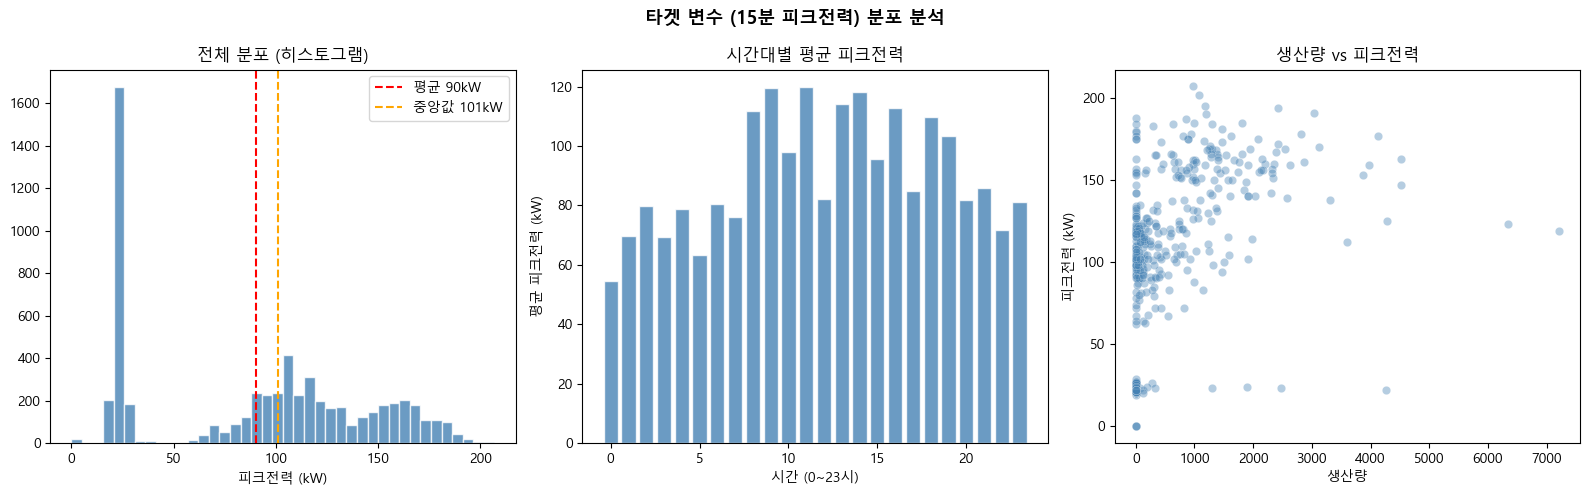


피크전력 고위험(≥130kW) 비율 : 26.9%


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('타겟 변수 (15분 피크전력) 분포 분석', fontsize=13, fontweight='bold')

# 1) 히스토그램
axes[0].hist(df['15분'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['15분'].mean(),   color='red',    linestyle='--', label=f"평균 {df['15분'].mean():.0f}kW")
axes[0].axvline(df['15분'].median(), color='orange', linestyle='--', label=f"중앙값 {df['15분'].median():.0f}kW")
axes[0].set_title('전체 분포 (히스토그램)')
axes[0].set_xlabel('피크전력 (kW)')
axes[0].legend()

# 2) 시간대별 평균 피크전력
hourly = df[df['시간'] <= 23].groupby('시간')['15분'].mean()
axes[1].bar(hourly.index, hourly.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('시간대별 평균 피크전력')
axes[1].set_xlabel('시간 (0~23시)')
axes[1].set_ylabel('평균 피크전력 (kW)')

# 3) 생산량 vs 피크전력 산점도
sample = df[df['시간'] <= 23].sample(500, random_state=42)
axes[2].scatter(sample['생산량'], sample['15분'],
                alpha=0.4, color='steelblue', edgecolor='white', linewidth=0.3)
axes[2].set_title('생산량 vs 피크전력')
axes[2].set_xlabel('생산량')
axes[2].set_ylabel('피크전력 (kW)')

plt.tight_layout()
plt.show()

print(f"\n피크전력 고위험(≥130kW) 비율 : {(df['15분'] >= 130).mean()*100:.1f}%")

# Step 10

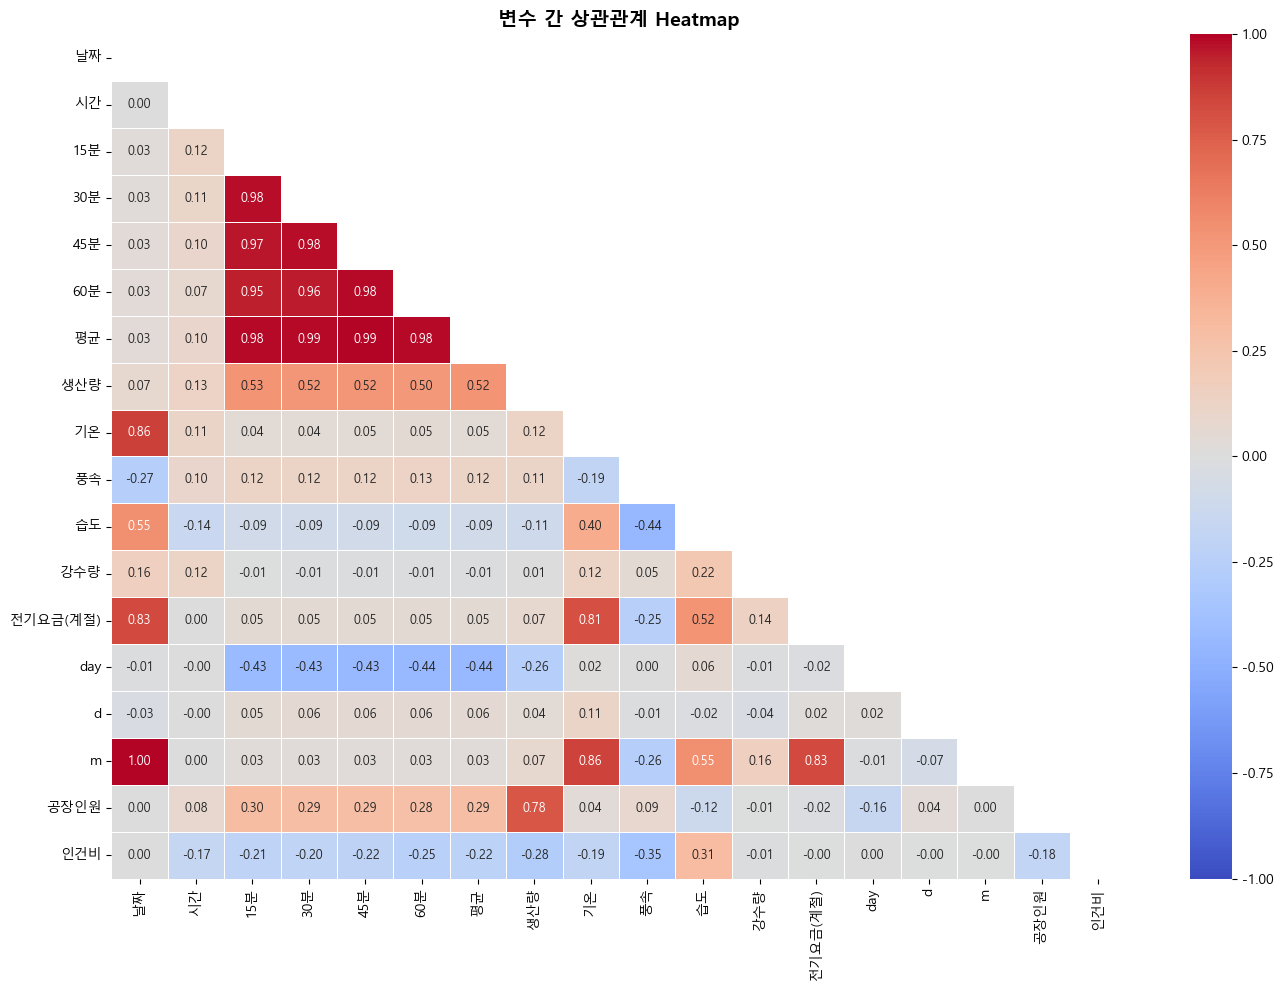

=== 15분 피크전력과의 상관계수 (절대값 내림차순) ===
생산량         0.526266
day         0.427823
공장인원        0.299105
인건비         0.208396
시간          0.120790
풍속          0.119570
습도          0.089654
d           0.053607
전기요금(계절)    0.050699
기온          0.043692
날짜          0.030397
m           0.028410
강수량         0.006896


In [15]:
# 이상치 제거 후 상관관계 계산
df_corr = df[df['시간'] <= 23].copy()

# 상관행렬
corr_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 상삼각 마스킹
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9}, vmin=-1, vmax=1)
plt.title('변수 간 상관관계 Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 타겟(15분)과의 상관계수 순위
print("=== 15분 피크전력과의 상관계수 (절대값 내림차순) ===")
target_corr = corr_matrix['15분'].drop(['15분','30분','45분','60분','평균']).abs()
print(target_corr.sort_values(ascending=False).to_string())

# Step 11

In [16]:
# ── 전처리 ────────────────────────────────────────────
df_clean = df.copy()

# 1) 이상치 제거: 시간 > 23
before = len(df_clean)
df_clean = df_clean[df_clean['시간'] <= 23]
print(f"[이상치 제거] 시간>23: {before - len(df_clean)}행 제거 → 잔여 {len(df_clean):,}행")

# 2) 결측치 처리
df_clean['풍속']   = df_clean['풍속'].fillna(df_clean['풍속'].median())
df_clean['강수량']  = df_clean['강수량'].fillna(0)   # 강수 없음으로 대체
df_clean['공장인원'] = df_clean['공장인원'].fillna(0)  # 비가동으로 대체
print(f"[결측치 처리] 완료 — 남은 결측치: {df_clean.isnull().sum().sum()}개")

# 3) 타겟 / 피처 분리
# ※ 30분/45분/60분/평균은 Data Leakage → 반드시 제외
TARGET = '15분'
LEAK_COLS = ['30분', '45분', '60분', '평균']  # 타겟과 같은 계열 → 제외
DROP_COLS  = ['날짜'] + LEAK_COLS              # 날짜는 시계열 특성 대신 d/m으로 대체

feature_cols = [c for c in df_clean.columns if c not in [TARGET] + DROP_COLS]

X = df_clean[feature_cols].copy()
y = df_clean[TARGET].copy()

print(f"\n[피처 구성]")
print(f"  사용 피처 수 : {len(feature_cols)}개")
print(f"  피처 목록    : {feature_cols}")
print(f"\n  X shape : {X.shape}")
print(f"  y shape : {y.shape}")
print(f"\n  타겟(y) 통계 → 평균: {y.mean():.1f}kW / 최대: {y.max()}kW / 최소: {y.min()}kW")

[이상치 제거] 시간>23: 48행 제거 → 잔여 6,120행
[결측치 처리] 완료 — 남은 결측치: 0개

[피처 구성]
  사용 피처 수 : 12개
  피처 목록    : ['시간', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']

  X shape : (6120, 12)
  y shape : (6120,)

  타겟(y) 통계 → 평균: 90.1kW / 최대: 207kW / 최소: 0kW


# Step 12

## 변수 조합 설계 — Feature Set A / B / C

현실에서 공장 담당자가 **예측 시점에 알 수 있는 정보**만으로 피처를 구성합니다.

| Feature Set | 변수 구성 | 설명 |
|---|---|---|
| **Set A (핵심)** | 시간, 생산량, 공장인원, day, d, m | 공정 핵심 변수만 |
| **Set B (핵심+환경)** | Set A + 기온, 습도, 풍속, 강수량 | 날씨 변수 추가 |
| **Set C (전체)** | 전체 12개 변수 | 전기요금(계절), 인건비 포함 |

→ 3가지 Feature Set을 모두 학습해서 변수 추가 효과를 비교합니다.

# Step 13

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Feature Set 정의 ──────────────────────────────────
FEATURE_SETS = {
    'Set_A': ['시간', '생산량', '공장인원', 'day', 'd', 'm'],
    'Set_B': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량'],
    'Set_C': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비'],
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS.items():
    print(f"  {name} ({len(cols)}개): {cols}")

# ── Set_C 기준 Train/Test Split (80:20) ──────────────
X_all  = X[FEATURE_SETS['Set_C']]
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ── Feature Set별 분할 딕셔너리 ──────────────────────
splits = {}
for name, cols in FEATURE_SETS.items():
    splits[name] = {
        'X_train': X_train_all[cols],
        'X_test' : X_test_all[cols],
    }

# ── 스케일링 (DNN, 선형모델용) ────────────────────────
scalers = {}
for name, cols in FEATURE_SETS.items():
    sc = StandardScaler()
    splits[name]['X_train_sc'] = sc.fit_transform(splits[name]['X_train'])
    splits[name]['X_test_sc']  = sc.transform(splits[name]['X_test'])
    scalers[name] = sc

print(f"\n✅ Split 완료")
print(f"   학습 데이터: {X_train_all.shape[0]:,}행")
print(f"   테스트 데이터: {X_test_all.shape[0]:,}행")

# Step 14

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model_name, y_true, y_pred):
    """회귀 모델 성능 평가 지표 계산"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'모델': model_name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R²': round(r2,4)}

all_results = []   # 전체 결과 저장 리스트
print("✅ 평가 함수 정의 완료")

✅ 평가 함수 정의 완료


# Step 15

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Feature Set 정의 ──────────────────────────────────
FEATURE_SETS = {
    'Set_A': ['시간', '생산량', '공장인원', 'day', 'd', 'm'],
    'Set_B': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량'],
    'Set_C': ['시간', '생산량', '공장인원', 'day', 'd', 'm',
              '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비'],
}

print("=== Feature Set 구성 ===")
for name, cols in FEATURE_SETS.items():
    print(f"  {name} ({len(cols)}개): {cols}")

# ── Set_C 기준 Train/Test Split (80:20) ──────────────
X_all  = X[FEATURE_SETS['Set_C']]
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# ── Feature Set별 분할 딕셔너리 ──────────────────────
splits = {}
for name, cols in FEATURE_SETS.items():
    splits[name] = {
        'X_train': X_train_all[cols],
        'X_test' : X_test_all[cols],
    }

# ── 스케일링 (DNN, 선형모델용) ────────────────────────
scalers = {}
for name, cols in FEATURE_SETS.items():
    sc = StandardScaler()
    splits[name]['X_train_sc'] = sc.fit_transform(splits[name]['X_train'])
    splits[name]['X_test_sc']  = sc.transform(splits[name]['X_test'])
    scalers[name] = sc

# ── 결과 저장 리스트 초기화 ───────────────────────────
all_results = []

print(f"\n✅ Split 완료")
print(f"   학습 데이터  : {X_train_all.shape[0]:,}행")
print(f"   테스트 데이터: {X_test_all.shape[0]:,}행")
print(f"   all_results  : 초기화 완료")

=== Feature Set 구성 ===
  Set_A (6개): ['시간', '생산량', '공장인원', 'day', 'd', 'm']
  Set_B (10개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량']
  Set_C (12개): ['시간', '생산량', '공장인원', 'day', 'd', 'm', '기온', '습도', '풍속', '강수량', '전기요금(계절)', '인건비']

✅ Split 완료
   학습 데이터  : 4,896행
   테스트 데이터: 1,224행
   all_results  : 초기화 완료


# Step 16

In [20]:
from sklearn.tree import DecisionTreeRegressor

print("=" * 55)
print("  [모델 3] Decision Tree Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
    dt.fit(Xtr, y_train)
    res = evaluate_model(f'DecisionTree [{fs_name}]', y_test, dt.predict(Xte))
    all_results.append(res)
    print(f"  DecisionTree {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

print()
print("💡 단일 트리 해설: R²≈0.88 → 선형 모델 대비 크게 향상")
print("   단, 단일 트리는 분기점에서 과적합 가능성 존재")
print("   → Random Forest(앙상블)로 개선 가능")

  [모델 3] Decision Tree Regressor
  DecisionTree Set_A  | RMSE= 16.89 | MAE=  9.45 | R²=0.9102
  DecisionTree Set_B  | RMSE= 18.50 | MAE= 10.26 | R²=0.8923
  DecisionTree Set_C  | RMSE= 18.51 | MAE= 10.28 | R²=0.8922

💡 단일 트리 해설: R²≈0.88 → 선형 모델 대비 크게 향상
   단, 단일 트리는 분기점에서 과적합 가능성 존재
   → Random Forest(앙상블)로 개선 가능


# Step 17

In [21]:
from sklearn.ensemble import RandomForestRegressor

print("=" * 55)
print("  [모델 4] Random Forest Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(Xtr, y_train)
    res = evaluate_model(f'RandomForest [{fs_name}]', y_test, rf.predict(Xte))
    all_results.append(res)
    print(f"  RandomForest {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

# Set_C 모델 저장 (Feature Importance용)
rf_setC = RandomForestRegressor(n_estimators=200, max_depth=15,
                                min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_setC.fit(splits['Set_C']['X_train'], y_train)

print()
print("💡 Random Forest 해설: R²≈0.94 → 현재까지 최고 성능")
print("   200개 트리의 평균 → 단일 트리보다 분산 감소, 과적합 억제")

  [모델 4] Random Forest Regressor
  RandomForest Set_A  | RMSE= 13.07 | MAE=  7.53 | R²=0.9463
  RandomForest Set_B  | RMSE= 14.19 | MAE=  8.46 | R²=0.9366
  RandomForest Set_C  | RMSE= 14.26 | MAE=  8.47 | R²=0.9359

💡 Random Forest 해설: R²≈0.94 → 현재까지 최고 성능
   200개 트리의 평균 → 단일 트리보다 분산 감소, 과적합 억제


# Step 18

In [22]:
from xgboost import XGBRegressor

print("=" * 55)
print("  [모델 5] XGBoost Regressor")
print("=" * 55)

for fs_name in FEATURE_SETS:
    Xtr = splits[fs_name]['X_train']
    Xte = splits[fs_name]['X_test']

    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb.fit(Xtr, y_train,
            eval_set=[(Xte, y_test)],
            verbose=False)
    res = evaluate_model(f'XGBoost [{fs_name}]', y_test, xgb.predict(Xte))
    all_results.append(res)
    print(f"  XGBoost {fs_name:6s} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")

# Set_C 모델 저장
xgb_setC = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, verbosity=0)
xgb_setC.fit(splits['Set_C']['X_train'], y_train, verbose=False)

print()
print("💡 XGBoost 해설: 부스팅(이전 트리의 오차를 다음 트리가 학습)")
print("   learning_rate=0.1: 학습 속도, 낮을수록 신중하게 학습")
print("   subsample=0.8: 매 트리마다 80% 샘플만 사용 → 과적합 방지")

  [모델 5] XGBoost Regressor
  XGBoost Set_A  | RMSE= 12.36 | MAE=  7.94 | R²=0.9519
  XGBoost Set_B  | RMSE= 13.20 | MAE=  8.30 | R²=0.9451
  XGBoost Set_C  | RMSE= 13.33 | MAE=  8.47 | R²=0.9441

💡 XGBoost 해설: 부스팅(이전 트리의 오차를 다음 트리가 학습)
   learning_rate=0.1: 학습 속도, 낮을수록 신중하게 학습
   subsample=0.8: 매 트리마다 80% 샘플만 사용 → 과적합 방지


# Step 19

In [23]:
from sklearn.neural_network import MLPRegressor

print("=" * 55)
print("  [모델 6] DNN (sklearn MLPRegressor)")
print("=" * 55)
print("  ※ DNN은 스케일링 필수 → StandardScaler 적용 버전 사용")
print()

dnn_configs = {
    'DNN-Shallow [64]'       : (64,),
    'DNN-Medium  [128,64]'   : (128, 64),
    'DNN-Deep    [128,64,32]': (128, 64, 32),
}

# Set_C 기준으로만 DNN 실행
Xtr_sc = splits['Set_C']['X_train_sc']
Xte_sc = splits['Set_C']['X_test_sc']

for dnn_name, layers in dnn_configs.items():
    dnn = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,       # 과적합 방지 자동 조기종료
        validation_fraction=0.1,   # train의 10%를 검증용으로 사용
        random_state=42
    )
    dnn.fit(Xtr_sc, y_train)
    res = evaluate_model(f'{dnn_name} [Set_C]', y_test, dnn.predict(Xte_sc))
    all_results.append(res)
    print(f"  {dnn_name} | RMSE={res['RMSE']:6.2f} | MAE={res['MAE']:6.2f} | R²={res['R²']:.4f}")
    print(f"              → 실제 학습 에포크: {dnn.n_iter_}회 (early stopping)")

# 최적 DNN 저장 (Medium)
dnn_best = MLPRegressor(hidden_layer_sizes=(128,64), activation='relu',
                        solver='adam', max_iter=500, early_stopping=True,
                        validation_fraction=0.1, random_state=42)
dnn_best.fit(Xtr_sc, y_train)

print()
print("💡 DNN 해설: 입력(12) → [128 → 64] → 출력(1)")
print("   ReLU: 음수는 0, 양수는 그대로 통과 → 비선형성 학습")
print("   early_stopping: 검증 손실이 더 이상 줄지 않으면 자동 종료")
print("   ⚠️  DNN은 데이터 수 6,000행에서 RF보다 성능이 낮을 수 있음")
print("      (DNN은 수십만 행 이상에서 진가 발휘)")

  [모델 6] DNN (sklearn MLPRegressor)
  ※ DNN은 스케일링 필수 → StandardScaler 적용 버전 사용

  DNN-Shallow [64] | RMSE= 30.98 | MAE= 24.02 | R²=0.6979
              → 실제 학습 에포크: 500회 (early stopping)
  DNN-Medium  [128,64] | RMSE= 20.99 | MAE= 14.65 | R²=0.8613
              → 실제 학습 에포크: 354회 (early stopping)
  DNN-Deep    [128,64,32] | RMSE= 21.59 | MAE= 15.26 | R²=0.8532
              → 실제 학습 에포크: 168회 (early stopping)

💡 DNN 해설: 입력(12) → [128 → 64] → 출력(1)
   ReLU: 음수는 0, 양수는 그대로 통과 → 비선형성 학습
   early_stopping: 검증 손실이 더 이상 줄지 않으면 자동 종료
   ⚠️  DNN은 데이터 수 6,000행에서 RF보다 성능이 낮을 수 있음
      (DNN은 수십만 행 이상에서 진가 발휘)


# Step 20

In [24]:
results_df = pd.DataFrame(all_results)

print("=" * 65)
print("  전체 모델 × Feature Set 비교표 (R² 내림차순)")
print("=" * 65)
print(results_df.sort_values('R²', ascending=False).to_string(index=False))

  전체 모델 × Feature Set 비교표 (R² 내림차순)
                             모델  RMSE   MAE     R²
                XGBoost [Set_A] 12.36  7.94 0.9519
           RandomForest [Set_A] 13.07  7.53 0.9463
                XGBoost [Set_B] 13.20  8.30 0.9451
                XGBoost [Set_C] 13.33  8.47 0.9441
           RandomForest [Set_B] 14.19  8.46 0.9366
           RandomForest [Set_C] 14.26  8.47 0.9359
           DecisionTree [Set_A] 16.89  9.45 0.9102
           DecisionTree [Set_B] 18.50 10.26 0.8923
           DecisionTree [Set_C] 18.51 10.28 0.8922
   DNN-Medium  [128,64] [Set_C] 20.99 14.65 0.8613
DNN-Deep    [128,64,32] [Set_C] 21.59 15.26 0.8532
       DNN-Shallow [64] [Set_C] 30.98 24.02 0.6979


# Step 21

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

print("=" * 55)
print("  하이퍼파라미터 튜닝 — Random Forest (Set_C)")
print("  ※ Windows 환경: n_jobs=1 로 안정 실행")
print("  ※ 약 3~5분 소요됩니다...")
print("=" * 55)

Xtr = splits['Set_C']['X_train']
Xte = splits['Set_C']['X_test']

param_dist_rf = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features'    : ['sqrt', 'log2', 0.7],
}

rf_tuned = RandomizedSearchCV(
    estimator           = RandomForestRegressor(random_state=42, n_jobs=1),  # ✅ 수정
    param_distributions = param_dist_rf,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = 1,   # ✅ 수정: Windows 병렬처리 충돌 방지
    verbose             = 1
)
rf_tuned.fit(Xtr, y_train)

print(f"\n✅ 최적 파라미터: {rf_tuned.best_params_}")
print(f"   CV R² (학습) : {rf_tuned.best_score_:.4f}")

res = evaluate_model('RF_Tuned [Set_C]', y_test, rf_tuned.predict(Xte))
all_results.append(res)
print(f"   Test  R²     : {res['R²']:.4f} / RMSE: {res['RMSE']} / MAE: {res['MAE']}")

  하이퍼파라미터 튜닝 — Random Forest (Set_C)
  ※ Windows 환경: n_jobs=1 로 안정 실행
  ※ 약 3~5분 소요됩니다...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ 최적 파라미터: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_depth': None}
   CV R² (학습) : 0.9066
   Test  R²     : 0.9360 / RMSE: 14.26 / MAE: 8.72


# Step 22

In [28]:
from xgboost import XGBRegressor

print("=" * 55)
print("  하이퍼파라미터 튜닝 — XGBoost (Set_C)")
print("  ※ Windows 환경: n_jobs=1 로 안정 실행")
print("  ※ 약 3~5분 소요됩니다...")
print("=" * 55)

param_dist_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_tuned = RandomizedSearchCV(
    estimator           = XGBRegressor(random_state=42, verbosity=0, n_jobs=1),  # ✅ 수정
    param_distributions = param_dist_xgb,
    n_iter              = 20,
    cv                  = 3,
    scoring             = 'r2',
    random_state        = 42,
    n_jobs              = 1,   # ✅ 수정: Windows 병렬처리 충돌 방지
    verbose             = 1
)
xgb_tuned.fit(splits['Set_C']['X_train'], y_train)

print(f"\n✅ 최적 파라미터: {xgb_tuned.best_params_}")
print(f"   CV R² (학습) : {xgb_tuned.best_score_:.4f}")

res = evaluate_model('XGB_Tuned [Set_C]', y_test, xgb_tuned.predict(splits['Set_C']['X_test']))
all_results.append(res)
print(f"   Test  R²     : {res['R²']:.4f} / RMSE: {res['RMSE']} / MAE: {res['MAE']}")

  하이퍼파라미터 튜닝 — XGBoost (Set_C)
  ※ Windows 환경: n_jobs=1 로 안정 실행
  ※ 약 3~5분 소요됩니다...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ 최적 파라미터: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
   CV R² (학습) : 0.9306
   Test  R²     : 0.9481 / RMSE: 12.84 / MAE: 8.0


# Step 23

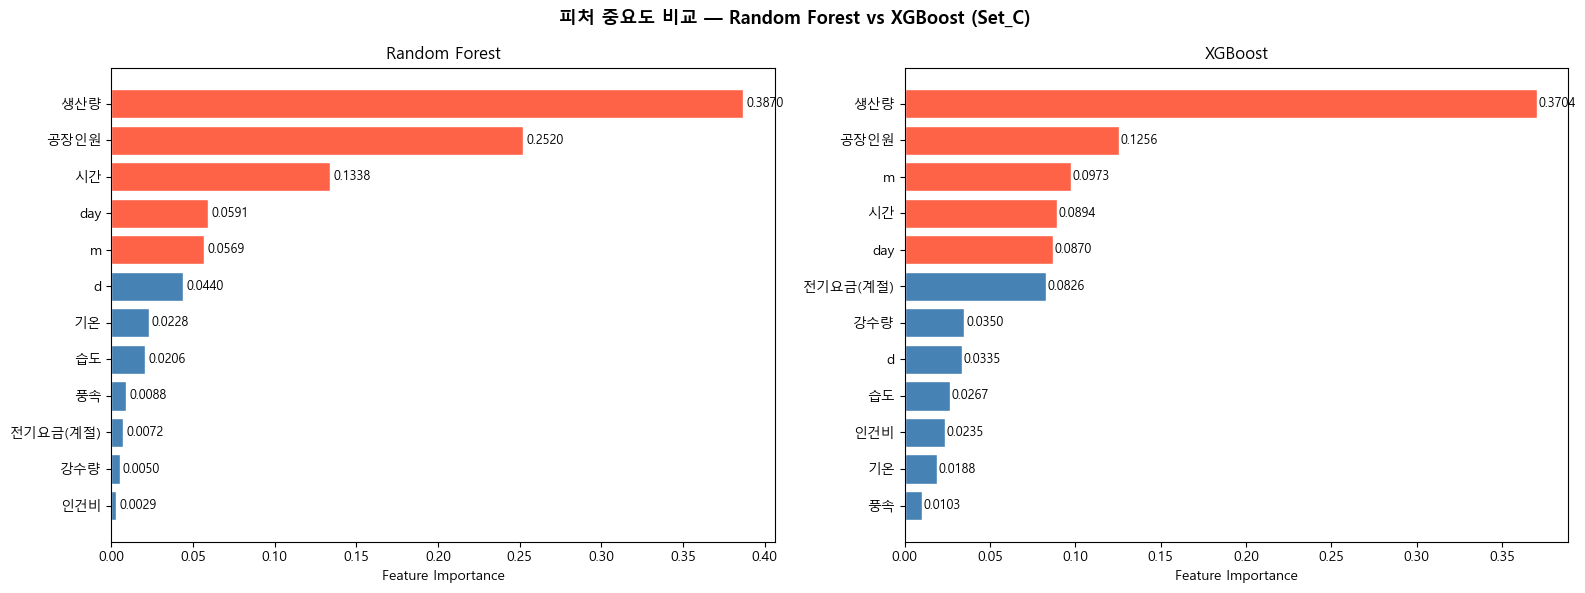


=== RF Feature Importance Top 5 ===
생산량     0.387022
공장인원    0.251998
시간      0.133800
day     0.059083
m       0.056860

=== XGBoost Feature Importance Top 5 ===
생산량     0.370351
공장인원    0.125598
m       0.097304
시간      0.089377
day     0.086957


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('피처 중요도 비교 — Random Forest vs XGBoost (Set_C)', fontsize=13, fontweight='bold')

feature_names = FEATURE_SETS['Set_C']

# RF Feature Importance
fi_rf = pd.Series(rf_setC.feature_importances_, index=feature_names).sort_values(ascending=True)
colors_rf = ['tomato' if v > fi_rf.quantile(0.6) else 'steelblue' for v in fi_rf.values]
axes[0].barh(fi_rf.index, fi_rf.values, color=colors_rf, edgecolor='white')
axes[0].set_title('Random Forest', fontsize=12)
axes[0].set_xlabel('Feature Importance')
for i, val in enumerate(fi_rf.values):
    axes[0].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

# XGBoost Feature Importance
fi_xgb = pd.Series(xgb_setC.feature_importances_, index=feature_names).sort_values(ascending=True)
colors_xgb = ['tomato' if v > fi_xgb.quantile(0.6) else 'steelblue' for v in fi_xgb.values]
axes[1].barh(fi_xgb.index, fi_xgb.values, color=colors_xgb, edgecolor='white')
axes[1].set_title('XGBoost', fontsize=12)
axes[1].set_xlabel('Feature Importance')
for i, val in enumerate(fi_xgb.values):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== RF Feature Importance Top 5 ===")
print(fi_rf.sort_values(ascending=False).head(5).to_string())
print("\n=== XGBoost Feature Importance Top 5 ===")
print(fi_xgb.sort_values(ascending=False).head(5).to_string())

# Step 24

In [ ]:
results_df = pd.DataFrame(all_results)

# Set_C 결과만 필터링해서 보기
setC_results = results_df[results_df['모델'].str.contains('Set_C')].sort_values('R²', ascending=False)

print("=" * 65)
print("  최종 모델 성능 비교 (Set_C 기준)")
print("=" * 65)
print(setC_results.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('최종 모델 성능 비교 (Set_C)', fontsize=13, fontweight='bold')

model_labels = [m.split('[')[0].strip() for m in setC_results['모델']]
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(setC_results))]

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    bars = ax.bar(model_labels, setC_results[metric], color=colors, edgecolor='white')
    ax.set_title(f'{metric}', fontsize=12)
    ax.set_xticklabels(model_labels, rotation=30, ha='right', fontsize=9)
    for bar, val in zip(bars, setC_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    if metric == 'R²':
        ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Step 25

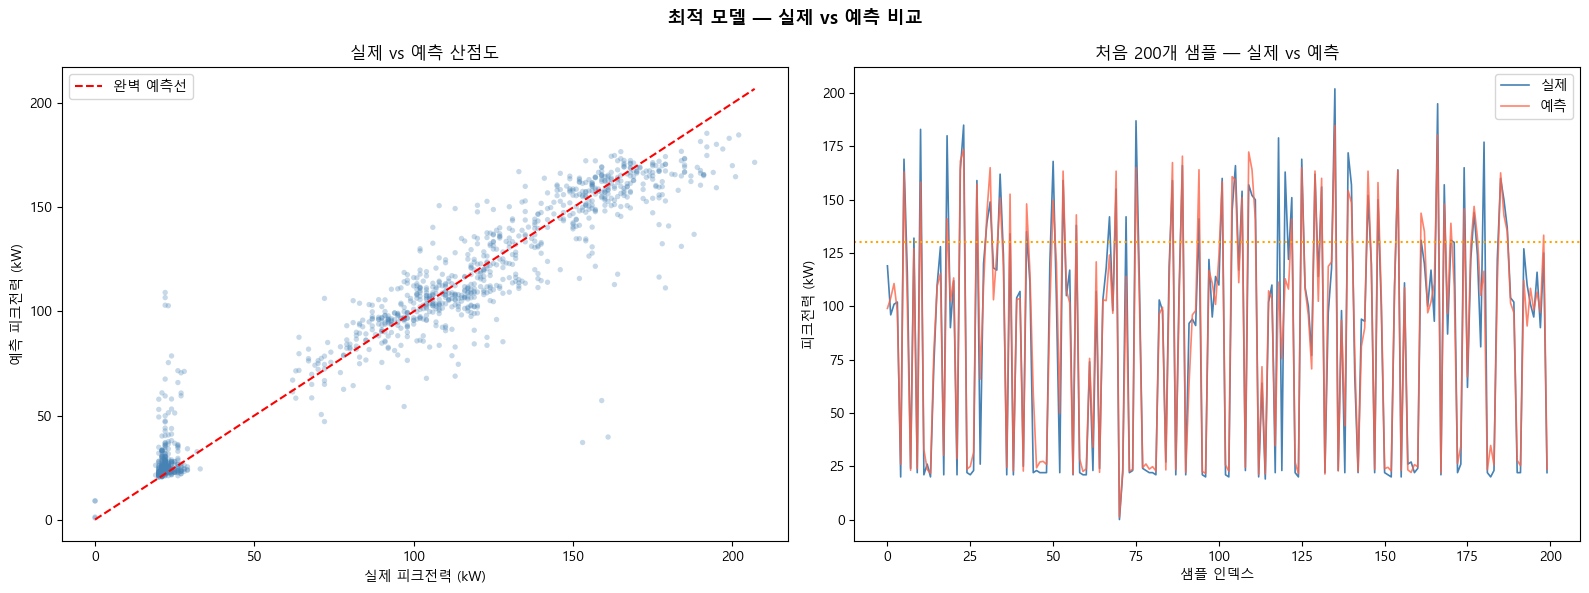


최적 모델 최종 성능
  RMSE : 14.26 kW  (평균 피크 90kW 대비 오차율 15.8%)
  R²   : 0.9360


In [30]:
# 최적 모델로 예측
best_model = rf_tuned   # RF_Tuned 또는 XGB_Tuned 중 R²가 높은 것
y_pred_best = best_model.predict(splits['Set_C']['X_test'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('최적 모델 — 실제 vs 예측 비교', fontsize=13, fontweight='bold')

# 1) 산점도
axes[0].scatter(y_test, y_pred_best, alpha=0.3, color='steelblue', edgecolor='none', s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='완벽 예측선')
axes[0].set_xlabel('실제 피크전력 (kW)')
axes[0].set_ylabel('예측 피크전력 (kW)')
axes[0].set_title('실제 vs 예측 산점도')
axes[0].legend()

# 2) 처음 200개 시계열 비교
idx = range(200)
axes[1].plot(idx, list(y_test)[:200],      label='실제', color='steelblue', linewidth=1.2)
axes[1].plot(idx, y_pred_best[:200], label='예측', color='tomato',    linewidth=1.2, alpha=0.8)
axes[1].set_xlabel('샘플 인덱스')
axes[1].set_ylabel('피크전력 (kW)')
axes[1].set_title('처음 200개 샘플 — 실제 vs 예측')
axes[1].legend()
axes[1].axhline(130, color='orange', linestyle=':', linewidth=1.5, label='고피크 기준(130kW)')

plt.tight_layout()
plt.show()

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"\n최적 모델 최종 성능")
print(f"  RMSE : {rmse_final:.2f} kW  (평균 피크 90kW 대비 오차율 {rmse_final/y.mean()*100:.1f}%)")
print(f"  R²   : {r2_score(y_test, y_pred_best):.4f}")

# Step 26

In [31]:
import joblib
import os
from sklearn.pipeline import Pipeline

os.makedirs('./models', exist_ok=True)

# 최적 파라미터로 파이프라인 구성
best_params = rf_tuned.best_params_

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),                        # 스케일링 (RF는 불필요하지만 통일성 유지)
    ('model' , RandomForestRegressor(
        **best_params,
        random_state=42,
        n_jobs=-1
    ))
])

# Set_C 피처로 재학습
final_pipeline.fit(splits['Set_C']['X_train'], y_train)

# 저장
save_path = './models/energy_pipeline.pkl'
joblib.dump({
    'pipeline'    : final_pipeline,
    'feature_cols': FEATURE_SETS['Set_C'],
    'scaler'      : scalers['Set_C'],
    'best_params' : best_params,
}, save_path)

size_mb = os.path.getsize(save_path) / (1024**2)
print(f"✅ 모델 저장 완료: {save_path}  ({size_mb:.2f} MB)")

# 로드 후 검증
loaded = joblib.load(save_path)
y_check = loaded['pipeline'].predict(splits['Set_C']['X_test'])
print(f"   로드 후 R² 검증: {r2_score(y_test, y_check):.4f}  ✅")

✅ 모델 저장 완료: ./models/energy_pipeline.pkl  (67.00 MB)
   로드 후 R² 검증: 0.9360  ✅
